# Part 2 · Circuits / Digital Quantum Computing

In Part 1, quantum states were static mathematical objects that we inspected with numpy. Now we **operate** on them. The **digital** (gate-model) paradigm builds programs as **circuits** of discrete **gates** and then **executes** them on a backend, much the way a classical program is a sequence of logic-gate operations executed on a CPU.

This is the model behind the best-known quantum algorithms: Shor's factoring algorithm (the reason post-quantum cryptography is now a field), Grover's search, and the quantum-chemistry circuits of Part 4. Running those at useful sizes needs larger and cleaner machines than 2026 hardware provides. One gate-model application, though, is already useful at small scale: certified quantum random number generation, in which the physics of measurement guarantees the bits are unpredictable. You build one in this notebook.

By the end of this notebook you will be able to:

- assemble a **`Circuit`** from gates and understand each gate as a **unitary matrix** acting on the state;
- **run** a circuit on the **`QiliSim`** simulator and read out **sampled** vs **exact** results;
- see **interference**, the effect behind Part 1's relative phase and the mechanism every quantum algorithm relies on;
- prepare multi-qubit **entanglement** gate by gate and use it as a shared secret;
- build a provably fair **quantum dice roller**, a toy-size quantum random number generator.

### The one execution pattern

Everything you run in QiliSDK, in this notebook and for the rest of the tutorial, goes through a single call:

$$\texttt{Backend.execute(functional, readout)} \;\longrightarrow\; \texttt{Result}$$

A **Functional** says *what* to run, a **Backend** says *where*, and a **Readout** says *what to measure*. A claim we will demonstrate by Part 6: **the same functional and readout run on any backend, CPU, GPU, or QPU (quantum processing unit, the actual quantum chip), by changing one line.**

In [1]:
# ▶ Run me first. No-op if QiliSDK is already installed; installs it on a fresh env (e.g. Google Colab).
try:
    import qilisdk
except ImportError:
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "qilisdk==0.2.1"], check=True)
    import qilisdk  # Colab: if this still fails, Runtime > Restart session, then rerun
print("QiliSDK", qilisdk.__version__)

QiliSDK 0.2.1


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## 2.1 · Gates & circuits

Quantum **gates** are how we *change* a state. Mathematically, a gate on $n$ qubits is a $2^n \times 2^n$ **unitary matrix** $U$. Unitary means $U^\dagger U = I$, where the **dagger** $\dagger$ is the conjugate transpose (in numpy: `U.conj().T`). Unitarity has two consequences:

- gates are **reversible**: the inverse of $U$ is simply $U^\dagger$, so any measurement-free circuit can be run backwards;
- gates **preserve the norm** of the state, so the Born-rule probabilities from Part 1 keep summing to 1.

Applying a gate is plain matrix–vector multiplication: $|\psi'\rangle = U\,|\psi\rangle$. In code you apply an operator to a state with `@` (matrix multiplication), **never** `*`: in `QTensor`, `*` is element-wise / scalar multiplication and will silently give you the wrong vector. When reading nested `@` expressions, read them inside out, like $f(g(x))$: the innermost gate acts first.

Four gates you will use constantly:

- **Hadamard** $H = \tfrac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ turns certainty into a 50/50 superposition: $H|0\rangle = \tfrac{1}{\sqrt2}\,(|0\rangle + |1\rangle)$, the state Part 1 called $|+\rangle$. It is the gate that creates superposition from a definite state.
- **Pauli-$X$** $= \begin{pmatrix}0&1\\1&0\end{pmatrix}$ is the quantum NOT: $X|0\rangle = |1\rangle$ and $X|1\rangle = |0\rangle$. (Together with $Y$ and $Z$ these are the Pauli matrices from Part 1.)
- **Rotations** $R_X(\theta)$, $R_Y(\theta)$, $R_Z(\phi)$ are *continuously tunable* gates: the angle is a plain Python float, a knob you can turn. Adjusting such an angle until the output improves is exactly what the variational algorithms of Part 4 do. (For the curious: $R_X(\theta) = e^{-i\theta X/2}$ is a **matrix exponential**, like `scipy.linalg.expm`, the continuous analog of applying one big gate in many small slices.)
- **CNOT** (controlled-NOT) is a *two-qubit* gate: it flips the **target** qubit if and only if the **control** qubit is $|1\rangle$. In programmer terms it is `target ^= control` (an XOR), except that it also works when the control is in superposition.

CNOT's truth table, writing the control as the first digit and the target as the second:

| in (control, target) | out | why |
|---|---|---|
| $\lvert 00\rangle$ | $\lvert 00\rangle$ | control is 0: do nothing |
| $\lvert 01\rangle$ | $\lvert 01\rangle$ | control is 0: do nothing |
| $\lvert 10\rangle$ | $\lvert 11\rangle$ | control is 1: flip the target |
| $\lvert 11\rangle$ | $\lvert 10\rangle$ | control is 1: flip the target |

Applied to a control that is in superposition, CNOT is the standard way to **create entanglement**, as you will see shortly.

A **`Circuit`** is an ordered sequence of gates over qubits indexed $0, 1, 2, \dots$. You build it by calling `.add(...)`. Running a measurement-free circuit means multiplying its gate matrices into the initial state $|0\cdots0\rangle$. One subtlety about ordering: applying gate $A$ *then* gate $B$ to a state computes $B\,A\,|\psi\rangle$. The first gate you apply ends up rightmost, next to the state, exactly like function composition $f(g(x))$: read it inside out. QiliSDK handles that bookkeeping; you just `.add` gates in the order they happen in time.

The simplest possible circuit is one qubit, one $X$, one measurement. On the starting state $|0\rangle$ it behaves exactly like a classical NOT on a `0` bit, so we know precisely what to expect when we execute it in section 2.2: the outcome `'1'`, on every shot.

In [3]:
from qilisdk.digital import Circuit, H, X, Y, Z, I, CNOT, M, RX, RY, RZ

quantum_not = Circuit(1)         # a register of 1 qubit, starting in |0>
quantum_not.add(X(0))            # quantum NOT on qubit 0: |0> -> |1>
quantum_not.add(M(0))            # measure qubit 0
print(quantum_not)

Circuit(nqubits=1, gates=[X(0), M(0)])


### Gates up close: the matrix behind each one

Every gate object carries its unitary on **`.matrix`**, the exact numbers your circuit multiplies into the state. The gates we use throughout the tutorial fall into three groups:

- the **identity** $I$ (do nothing) and the three **Pauli** gates $X$ (bit flip), $Y$ (bit *and* phase flip), $Z$ (phase flip);
- the **Hadamard** $H$, which builds an equal superposition;
- the three **rotation** gates, which turn the qubit by an angle about one axis of the Bloch sphere:
  $$R_X(\theta)=e^{-i\theta X/2},\qquad R_Y(\theta)=e^{-i\theta Y/2},\qquad R_Z(\phi)=e^{-i\phi Z/2}.$$
  Their angle is a plain float, the knob a variational algorithm turns in Part 4. Note the keyword: `RX` and `RY` take `theta=`, while `RZ` takes `phi=`.

The cell below prints all eight matrices; the rotations are shown at a representative angle of $\pi/2$.

In [4]:
theta = np.pi / 2   # a representative angle for the rotation gates

for name, gate in [("I", I(0)), ("X", X(0)), ("Y", Y(0)), ("Z", Z(0)), ("H", H(0)),
                   ("RX(pi/2)", RX(0, theta=theta)),
                   ("RY(pi/2)", RY(0, theta=theta)),
                   ("RZ(pi/2)", RZ(0, phi=theta))]:
    print(f"{name:8} =\n{np.round(gate.matrix, 3)}\n")

I        =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

X        =
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Y        =
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Z        =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

H        =
[[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]

RX(pi/2) =
[[0.707+0.j    0.   -0.707j]
 [0.   -0.707j 0.707+0.j   ]]

RY(pi/2) =
[[ 0.707+0.j -0.707+0.j]
 [ 0.707+0.j  0.707+0.j]]

RZ(pi/2) =
[[0.707-0.707j 0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]



### What the gates do to your four states

Matrices are exact but hard to read at a glance. A more readable view is a **truth table**: take the four reference states from Part 1 and ask what each gate turns them into. The five **constant** gates map them cleanly (up to a phase):

| gate | $\lvert 0\rangle$ | $\lvert 1\rangle$ | $\lvert +\rangle$ | $\lvert -\rangle$ | in one phrase |
|---|---|---|---|---|---|
| $I$ | $\lvert 0\rangle$ | $\lvert 1\rangle$ | $\lvert +\rangle$ | $\lvert -\rangle$ | **identity**: leaves every state alone |
| $X$ | $\lvert 1\rangle$ | $\lvert 0\rangle$ | $\lvert +\rangle$ | $-\lvert -\rangle$ | **bit flip**: swaps the poles, fixes the equator |
| $Y$ | $i\lvert 1\rangle$ | $-i\lvert 0\rangle$ | $-i\lvert -\rangle$ | $i\lvert +\rangle$ | **bit + phase flip**: swaps both, with a factor of $i$ |
| $Z$ | $\lvert 0\rangle$ | $-\lvert 1\rangle$ | $\lvert -\rangle$ | $\lvert +\rangle$ | **phase flip**: fixes the poles, swaps the equator |
| $H$ | $\lvert +\rangle$ | $\lvert -\rangle$ | $\lvert 0\rangle$ | $\lvert 1\rangle$ | **basis swap**: turns poles into equator and back |

$X$ and $Z$ are mirror images: $X$ swaps the poles and fixes the equator, $Z$ does the reverse; $Y$ does both at once (with a factor of $i$). $H$ is the bridge between the two bases, which is why it turns a definite $|0\rangle$ into the fifty-fifty $|+\rangle$.

The **rotation** gates have no such clean table: at a general angle they send a basis state to a *superposition*. The code below verifies the constant-gate rows and shows what the rotations produce at $\theta = \pi/2$ (output amplitudes, not tidy labels). Watch the minus signs and $i$'s: they are **relative phases**, exactly the information a computational-basis measurement throws away.

In [5]:
from qilisdk.core import QTensor, ket           # states live in Core, gates in `digital`

refs = {
    "|0>": ket(0),
    "|1>": ket(1),
    "|+>": QTensor.uniform(1),
    "|->": (ket(0) - ket(1)).normalized(),
}

gates = [("I", I(0)), ("X", X(0)), ("Y", Y(0)), ("Z", Z(0)), ("H", H(0)),
         ("RX", RX(0, theta=np.pi / 2)), ("RY", RY(0, theta=np.pi / 2)), ("RZ", RZ(0, phi=np.pi / 2))]

for gname, gate in gates:
    U = QTensor(gate.matrix)                     # wrap the gate's matrix as an operator
    print(f"--- {gname} ---")
    for sname, s in refs.items():
        print(f"  {gname:<2} {sname:<4} -> {np.round((U @ s).dense().ravel(), 3)}")

--- I ---
  I  |0>  -> [1.+0.j 0.+0.j]
  I  |1>  -> [0.+0.j 1.+0.j]
  I  |+>  -> [0.707+0.j 0.707+0.j]
  I  |->  -> [ 0.707+0.j -0.707+0.j]
--- X ---
  X  |0>  -> [0.+0.j 1.+0.j]
  X  |1>  -> [1.+0.j 0.+0.j]
  X  |+>  -> [0.707+0.j 0.707+0.j]
  X  |->  -> [-0.707+0.j  0.707+0.j]
--- Y ---
  Y  |0>  -> [0.+0.j 0.+1.j]
  Y  |1>  -> [0.-1.j 0.+0.j]
  Y  |+>  -> [0.-0.707j 0.+0.707j]
  Y  |->  -> [0.+0.707j 0.+0.707j]
--- Z ---
  Z  |0>  -> [1.+0.j 0.+0.j]
  Z  |1>  -> [ 0.+0.j -1.+0.j]
  Z  |+>  -> [ 0.707+0.j -0.707+0.j]
  Z  |->  -> [0.707+0.j 0.707-0.j]
--- H ---
  H  |0>  -> [0.707+0.j 0.707+0.j]
  H  |1>  -> [ 0.707+0.j -0.707+0.j]
  H  |+>  -> [1.+0.j 0.+0.j]
  H  |->  -> [0.+0.j 1.+0.j]
--- RX ---
  RX |0>  -> [0.707+0.j    0.   -0.707j]
  RX |1>  -> [0.   -0.707j 0.707+0.j   ]
  RX |+>  -> [0.5-0.5j 0.5-0.5j]
  RX |->  -> [ 0.5+0.5j -0.5-0.5j]
--- RY ---
  RY |0>  -> [0.707+0.j 0.707+0.j]
  RY |1>  -> [-0.707+0.j  0.707+0.j]
  RY |+>  -> [0.+0.j 1.+0.j]
  RY |->  -> [ 1.+0.j -0.+0

### The same operations, on the Bloch sphere

The truth table is exact, but the geometry makes it stick. **Every single-qubit gate is a rotation of the Bloch sphere**, so "apply a gate" and "rotate the state's arrow" describe the same thing:

- the Paulis $X$, $Y$, $Z$ are **180° rotations** about the $X$-, $Y$-, and $Z$-axis;
- $H$ is a 180° rotation about the diagonal axis halfway between the $X$- and $Z$-axes;
- $R_X(\theta)$, $R_Y(\theta)$, $R_Z(\phi)$ rotate by their angle about the $X$-, $Y$-, and $Z$-axis;
- $I$ is the do-nothing rotation.

Below we apply **every gate to two starting states in turn** — first $|0\rangle$ (the north pole), then $|+\rangle$ (on the equator). A rotation is invisible when the state already lies on its axis: $Z$ and $R_Z$ leave $|0\rangle$ fixed but visibly act on $|+\rangle$, whereas $X$ and $R_X$ leave $|+\rangle$ fixed but act on $|0\rangle$. (From $|0\rangle$, $X$ and $Y$ both land on $|1\rangle$; they differ only by the phase the truth table showed, which the sphere does not display.)

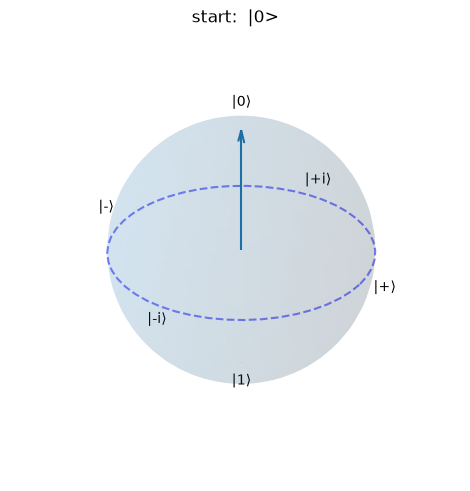

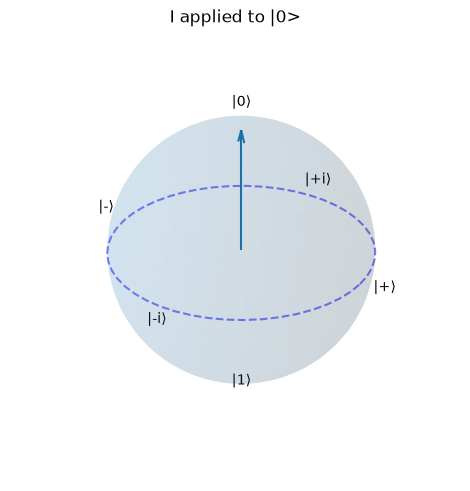

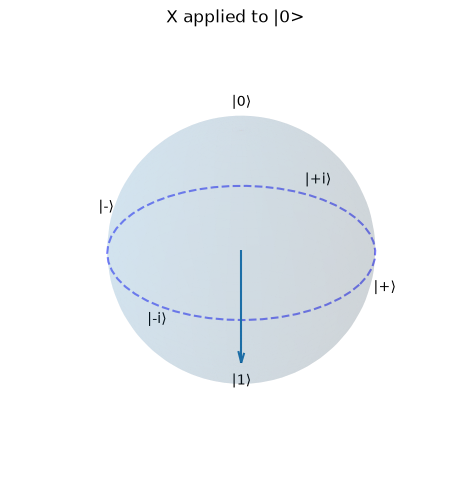

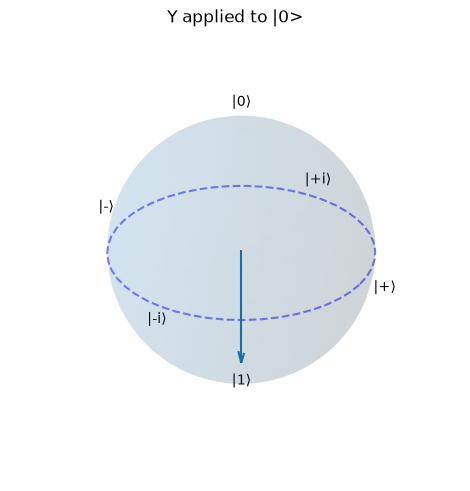

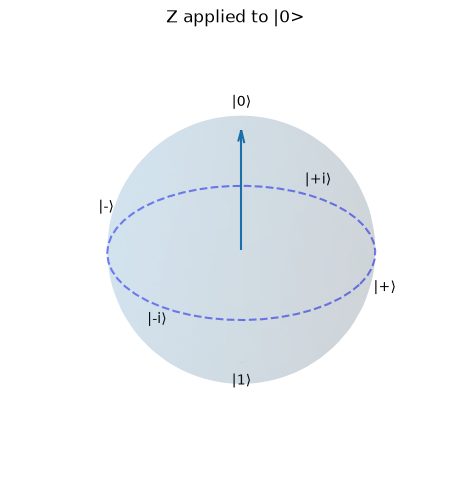

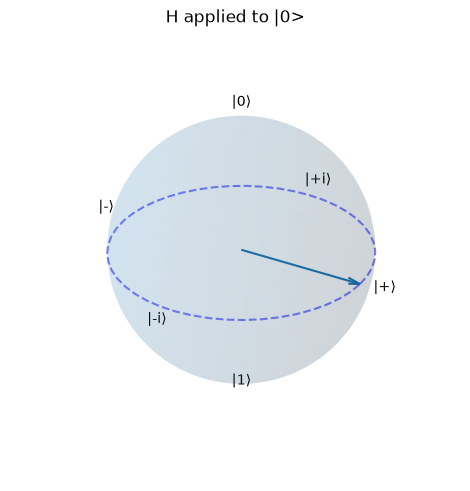

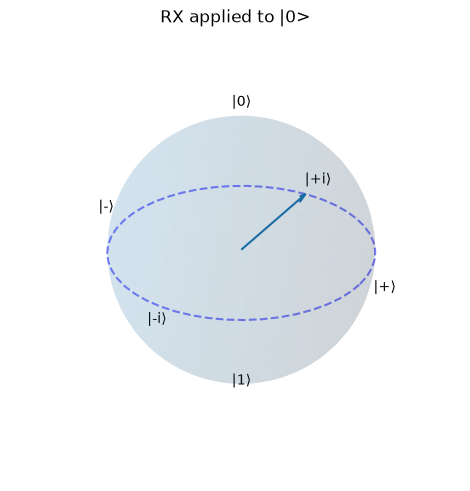

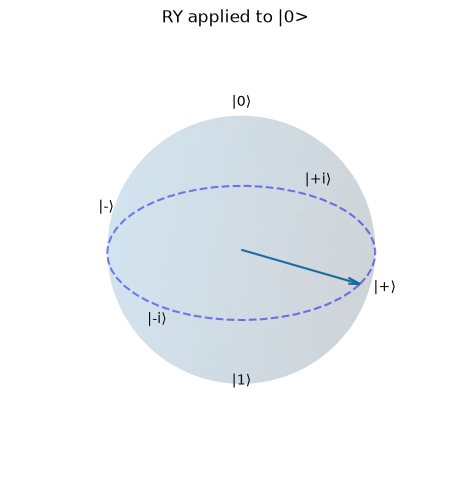

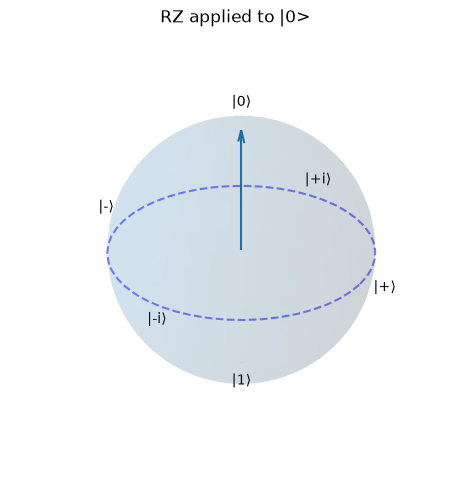

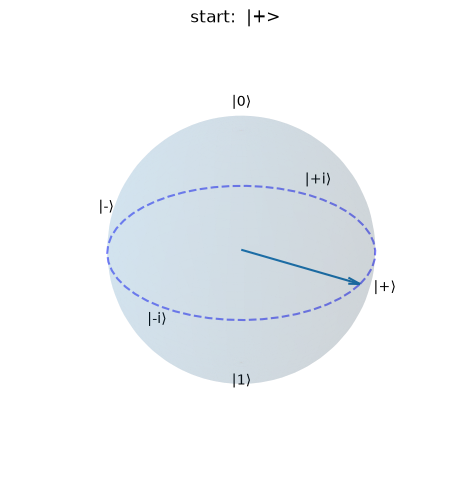

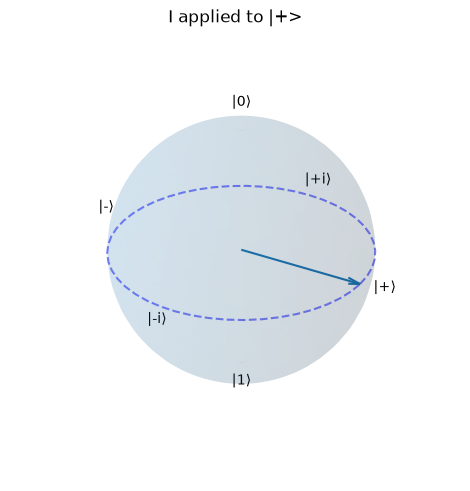

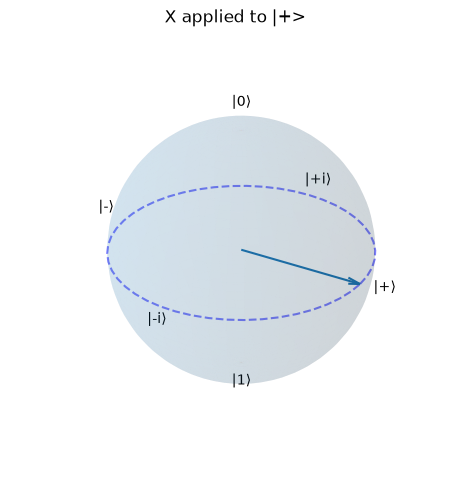

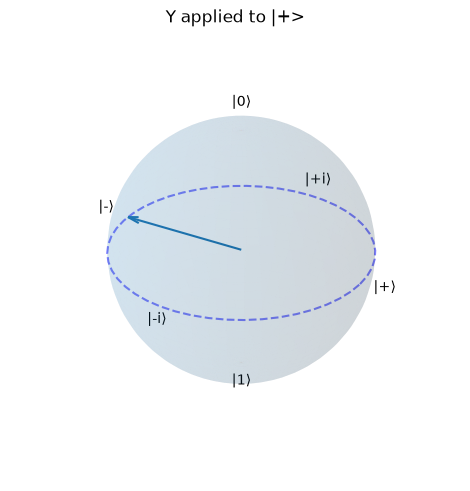

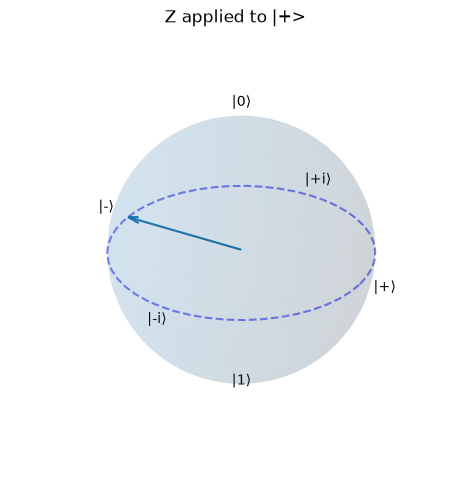

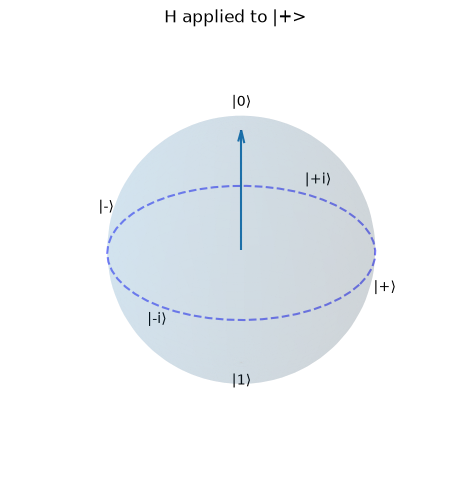

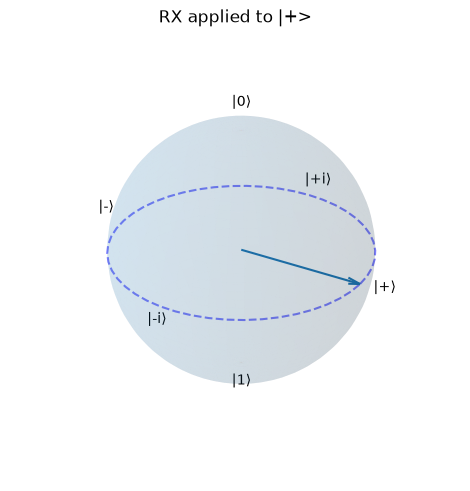

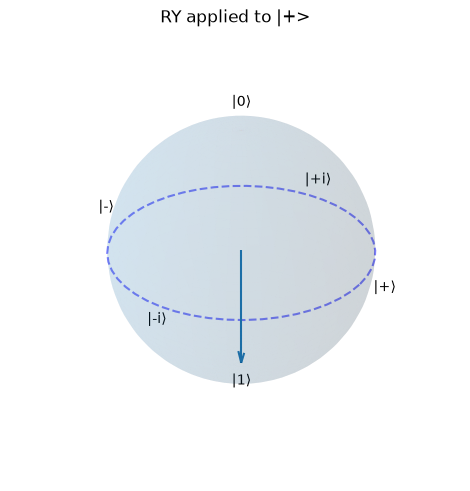

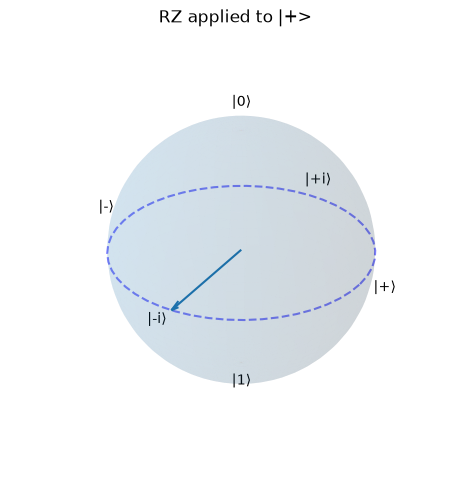

In [6]:
from qilisdk.utils.visualization import QTensorStyle

def gallery(title):
    return QTensorStyle(title=title, dpi=100)

gates = [
    ("I",  I(0)),
    ("X",  X(0)),
    ("Y",  Y(0)),
    ("Z",  Z(0)),
    ("H",  H(0)),
    ("RX", RX(0, theta=np.pi / 2)),
    ("RY", RY(0, theta=np.pi / 2)),
    ("RZ", RZ(0, phi=np.pi / 2)),
]

# Apply every gate to |0> first, then every gate to |+>, so you see each gate's effect from both.
for label, state in [("|0>", ket(0)), ("|+>", QTensor.uniform(1))]:
    state.draw(style=gallery(f"start:  {label}"))
    for name, gate in gates:
        after = QTensor(gate.matrix) @ state
        after.draw(style=gallery(f"{name} applied to {label}"))

### Interference: applying $H$ twice

$H$ is its own inverse: $H\,H = I$. Applying it to $|0\rangle$ produces the superposition $|+\rangle$ (the quarter-turn you just drew); applying it a second time returns **exactly** $|0\rangle$. That return is the simplest example of **interference**, the effect Part 1 said the relative phase makes possible: the two computational paths that would end in $|1\rangle$ arrive with opposite signs and cancel, while the two paths to $|0\rangle$ reinforce.

A classical coin behaves in the opposite way: flip it twice and the two random flips compound. Applying $H$ twice instead cancels the randomness completely. This cancellation is the mechanism every quantum algorithm depends on, and it is why the *sign* of an amplitude, invisible to a single measurement, still matters. We apply the gate here as a matrix (its `.matrix`) so the two steps are explicit; from 2.2 onward we run gates through the execution pattern instead.

In [7]:
Hm = QTensor(H(0).matrix)              # the Hadamard as an operator (read off .matrix)

step1 = Hm @ ket(0)                    # H|0> = |+>, an equal superposition
step2 = Hm @ step1                     # H(H|0>): the two paths to |1> cancel
print("H|0>    :", np.round(step1.dense().ravel(), 3))    # [0.707 0.707]
print("H(H|0>) :", np.round(step2.dense().ravel(), 3))    # [1. 0.]  -> back to |0>, exactly

H|0>    : [0.707+0.j 0.707+0.j]
H(H|0>) : [1.+0.j 0.+0.j]


**Measurement (`M`) is fundamentally different from a gate.** It is *not* unitary: it irreversibly **collapses** the superposition to a single classical bitstring, with probabilities given by the Born rule from Part 1. This is why a circuit that contains `M` has no single unitary matrix, and why an algorithm must arrange its interference *before* the measurement, while the state still holds all $2^n$ amplitudes; once you measure, only the sampled bits remain.

QiliSDK's gate set includes the single-qubit gates `H, X, Y, Z, S, T`, the parameterized rotations `RX, RY, RZ`, the general rotations `U1, U2, U3`, the two-qubit gates `CNOT, CZ, SWAP`, and the combinators `Controlled / Adjoint / Exponential`. One practical gotcha: **rotation angles are keyword-only**. You must write `RX(0, theta=1.57)`; a positional `RX(0, 1.57)` raises a `TypeError`.

A *measurement-free* circuit, by contrast, is one large unitary, and you can ask QiliSDK for its full $2^n \times 2^n$ matrix:

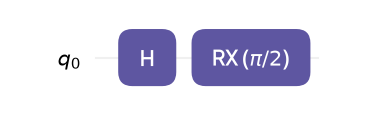

this circuit's unitary has shape: (2, 2)


In [8]:
u = Circuit(1)
u.add(H(0))
u.add(RX(0, theta=np.pi / 2))   # rotation angle is KEYWORD-ONLY
u.draw()                        # picture the circuit whose matrix we're about to build
print("this circuit's unitary has shape:", u.to_matrix().shape)   # (2, 2) = 2**1 x 2**1

## 2.2 · Running a circuit & reading out results

So far we have only *built* circuits. Executing one uses the universal pattern `Backend.execute(functional, readout)`, with three pieces:

1. **Functional**: *what* to run. A bare `Circuit` is not directly executable (QiliSDK raises if you try). You wrap it in **`DigitalPropagation`**, the functional that means "start from $|0\cdots0\rangle$ and propagate the state through this circuit's gates". Think of the functional as the job description and the circuit as one ingredient of it.
2. **Backend**: *where* to run. **`QiliSim`** is the built-in C++ simulator that ships with the pip install. Under the hood it does **state-vector simulation**: it stores all $2^n$ complex amplitudes in memory and applies each gate as a matrix multiply, so it always knows the exact final state. This is Part 1's memory wall in action: every extra qubit doubles the memory, so a laptop tops out in the low 30s of qubits. That wall is exactly why real quantum hardware is interesting.
3. **Readout**: *what* to extract. The fluent `Readout()` builder lets you ask for `with_sampling(...)` (measurement counts, like a real device), `with_expectation(...)` (observable averages, Part 1's $\langle O \rangle$), or `with_state_tomography()` (the exact final state, a simulator privilege we unpack below).

First execution: the one-qubit NOT circuit from 2.1. Quantum outcomes are only random when the measured state is in superposition, and $X|0\rangle = |1\rangle$ is not: it is a basis state. So every one of the 1000 shots must come out `'1'`:

In [9]:
from qilisdk.functionals import DigitalPropagation
from qilisdk.backends import QiliSim
from qilisdk.readout import Readout

result = QiliSim().execute(DigitalPropagation(quantum_not), Readout().with_sampling(nshots=1000))
print(result.get_samples())   # {'1': 1000}: deterministic, like a classical NOT

{'1': 1000}


All 1000 shots agree: `{'1': 1000}`. Quantum circuits are only random where you *put* randomness. For something genuinely random, take a single qubit and rotate it partway between $|0\rangle$ and $|1\rangle$ with an $R_X$ gate, so measuring it behaves like a *biased* coin. **Sampling** mimics a real device: it draws `nshots` measurement outcomes from the Born-rule distribution, so the counts are *empirical* and fluctuate from run to run. That statistical wobble is called **shot noise**, and it shrinks like $1/\sqrt{\text{nshots}}$: one more decimal digit of precision costs 100x more shots.

In [10]:
biased = Circuit(1)
biased.add(RX(0, theta=2 * np.pi / 3))   # rotate partway: P(0) = 0.25, P(1) = 0.75
biased.add(M(0))

biased_result = QiliSim().execute(DigitalPropagation(biased), Readout().with_sampling(nshots=1000))
print("samples      :", biased_result.get_samples())        # ~250 '0', ~750 '1'
print("probabilities:", biased_result.get_probabilities())  # empirical frequencies, near 0.25 / 0.75

samples      : {'0': 204, '1': 796}
probabilities: {'0': 0.204, '1': 0.796}


The sampled counts wobble around the true probabilities but never land exactly on them. Because we are on a **simulator**, we also have an option no real device has: we can read the **exact** probabilities straight from the stored state vector, with zero shot noise. The readout is called `with_state_tomography()`. The name comes from hardware practice, where **tomography** means reconstructing the full quantum state from many repeated measurements in different bases ("tomo" is Greek for slice, as in a CT scan). On hardware that reconstruction is expensive; on a simulator the state is already sitting in memory, so QiliSDK reuses the name for this free, exact readout.

Rule of thumb for the rest of the tutorial: use the **exact** path when you need reproducible numbers on screen, and **sampling** when you want to mimic what real hardware would return.

In [11]:
biased_exact = QiliSim().execute(DigitalPropagation(biased), Readout().with_state_tomography())
biased_probs = biased_exact.state_tomography.probabilities
print({k: round(p, 6) for k, p in biased_probs.items()})   # {'0': 0.25, '1': 0.75}, exactly

{'0': 0.25, '1': 0.75}


A histogram makes the sampled-vs-exact contrast visible. The bars show what we actually sampled; the dashed lines mark the exact expectation, $\text{nshots} \times p$, for each outcome. The bar-vs-line gap *is* shot noise:

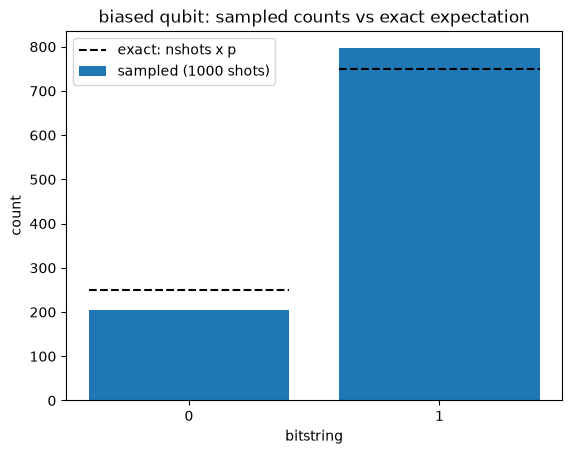

In [12]:
counts = biased_result.get_samples()
labels = sorted(biased_probs)                 # the two outcomes, '0' and '1'
positions = range(len(labels))

plt.bar(positions, [counts.get(k, 0) for k in labels], tick_label=labels, label="sampled (1000 shots)")
for i, k in enumerate(labels):
    expected = 1000 * biased_probs[k]
    plt.hlines(expected, i - 0.4, i + 0.4, colors="black", linestyles="dashed",
               label="exact: nshots x p" if i == 0 else None)
plt.title("biased qubit: sampled counts vs exact expectation")
plt.xlabel("bitstring")
plt.ylabel("count")
plt.legend()
plt.show()

## 2.3 · A provably fair quantum coin

This section builds the smallest genuinely useful quantum program: a random-bit generator. Random numbers underpin cryptography, lotteries, scientific simulation, and online gaming, and classical "randomness" shares one weakness: it is pseudo-random, produced by an algorithm that only *looks* unpredictable. Recover the seed and every draw can be replayed. Quantum measurement is different: the randomness of the Born rule is not a modeling convenience but, as far as physics can tell, fundamental.

The whole generator is one qubit and two operations:

1. **Make it uniform.** An $H$ on $|0\rangle$ gives $|+\rangle$, a 50/50 superposition of `0` and `1`.
2. **Prove fairness first.** The exact readout shows both outcomes at exactly $0.5$, *before* we trust a single shot. No classical coin or software RNG can give you that guarantee in advance.
3. **Flip it.** Each measurement shot is one physically random bit.

Structurally this is a commercial QRNG at toy scale: a uniform quantum source read out as classical bits. To produce a number in a range rather than a single bit you use more qubits and discard the outcomes you don't want, which is exactly the dice roller you build in the exercise.

One caveat: QiliSim is a simulator, so the randomness here is still pseudo-random underneath. The point is that this same circuit, unchanged, runs on real hardware (Part 6, `SpeQtrum`), where the physical guarantee becomes real.

In [13]:
# The whole generator: one qubit, one H, one measurement.
coin = Circuit(1)
coin.add(H(0))            # |0> -> |+>, a uniform superposition of 0 and 1
coin.add(M(0))

# Prove fairness BEFORE trusting a shot: the exact readout must be exactly 50/50.
coin_exact = QiliSim().execute(DigitalPropagation(coin), Readout().with_state_tomography())
print("exact probabilities:", {k: round(p, 4) for k, p in coin_exact.state_tomography.probabilities.items()})

# Flip it: each of the 1000 shots is one physically random bit.
flips = QiliSim().execute(DigitalPropagation(coin), Readout().with_sampling(nshots=1000)).get_samples()
print("1000 flips:", flips)

exact probabilities: {'0': 0.5, '1': 0.5}
1000 flips: {'0': 472, '1': 528}


### 🧩 Exercise 2.1: build a quantum dice roller

The coin above generates a single bit. A die needs a number in a range, which adds two ideas on top of the coin: use several qubits as the uniform source, and deal with the fact that the range you want rarely matches a power of two.

Build a **provably fair d6** (six-sided die):

1. Decide how many qubits a d6 needs: the smallest $n$ with $2^n \geq 6$ (here $n = 3$, giving $2^3 = 8$ raw outcomes).
2. Put every qubit in uniform superposition (an $H$ on each) and measure them all.
3. Prove fairness with the exact readout: every one of the $2^n$ raw outcomes should sit at exactly $1/2^n$.
4. Roll: sample 4000 shots, convert each bitstring to a face value with `int(bitstring, 2) + 1`, and keep only the values up to 6. Discarding the surplus outcomes (7 and 8) is **rejection sampling**, the same technique Python's `random.randrange` uses internally: it avoids the bias you would get from folding 8 outcomes into 6 with a modulo, at the cost of throwing some shots away. You expect to keep $6/8 = 75\%$ of them.
5. Report the keep rate and print the counts per face.

Hints: the coin demo above is your template for the build/execute/read-out pattern; the new parts are using several qubits and the rejection step. Remember that `.add` accepts a list of gates and that `M(*range(n))` measures the whole register.

In [14]:
from collections import Counter

# step 1 + 2: 3 qubits give 2**3 = 8 raw outcomes, the smallest power of two >= 6
n = 3
d6 = Circuit(n)
d6.add([H(q) for q in range(n)])
d6.add(M(*range(n)))

# step 3: fairness proof, every raw outcome at exactly 1/8 = 0.125
d6_exact = QiliSim().execute(DigitalPropagation(d6), Readout().with_state_tomography())
d6_probs = d6_exact.state_tomography.probabilities
print("outcomes:", len(d6_probs),
      "| min p:", round(min(d6_probs.values()), 6),
      "| max p:", round(max(d6_probs.values()), 6))

# step 4: roll it with rejection sampling
d6_result = QiliSim().execute(DigitalPropagation(d6), Readout().with_sampling(nshots=4000))
rolls = Counter()
kept = 0
for bitstring, count in d6_result.get_samples().items():
    value = int(bitstring, 2) + 1
    if value <= 6:
        rolls[value] += count
        kept += count

# step 5: keep rate and per-face counts
print(f"kept {kept} of 4000 raw samples ({kept / 4000:.0%}, expected 6/8 = 75%)")
print("rolls per face:", dict(sorted(rolls.items())))

outcomes: 8 | min p: 0.125 | max p: 0.125
kept 3009 of 4000 raw samples (75%, expected 6/8 = 75%)
rolls per face: {1: 458, 2: 483, 3: 530, 4: 529, 5: 475, 6: 534}


## 2.4 · Entanglement on a circuit

Two qubits let a circuit do something no single qubit can: **entangle** them, so their measurement outcomes are perfectly correlated. The standard recipe is the two-qubit **Bell circuit**, which prepares Part 1's entangled state $|\Phi^+\rangle$: an $H$ on qubit 0 creates a superposition, then `CNOT(0, 1)` spreads that correlation to qubit 1.

$$\text{CNOT}\,(H \otimes I)\,|00\rangle \;=\; \tfrac{1}{\sqrt2}\,\bigl(|00\rangle + |11\rangle\bigr).$$

Two notation reminders. $H \otimes I$ means "$H$ on qubit 0 and do-nothing ($I$) on qubit 1": the tensor product from Part 1 is how a 1-qubit gate becomes a 2-qubit operation. And CNOT sits to the *left* of $H \otimes I$ because it happens *second*: function composition, read inside out. `circuit.draw()` renders the two-qubit circuit, one horizontal wire per qubit.

Circuit(nqubits=2, gates=[H(0), CNOT(0, 1), M(0, 1)])


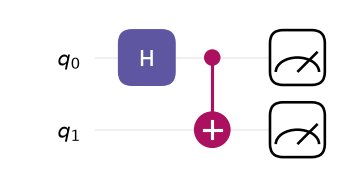

In [15]:
bell = Circuit(2)
bell.add(H(0))            # superposition on qubit 0
bell.add(CNOT(0, 1))      # control = 0, target = 1: entangles them
bell.add(M(0, 1))         # measure qubits 0 and 1
print(bell)
bell.draw()

We run it exactly as in 2.2 — wrap it in `DigitalPropagation`, sample it on `QiliSim`, and read the counts. Only `00` and `11` ever appear: the two qubits always agree, but *which* value they agree on is a fair coin flip. This is what entanglement looks like when you measure it. (Bitstring convention: QiliSDK's sample keys are **big-endian**, so the *first* character is qubit 0.)

In [16]:
bell_result = QiliSim().execute(DigitalPropagation(bell), Readout().with_sampling(nshots=1000))
print("samples      :", bell_result.get_samples())          # only '00' and '11', roughly 500 each
print("probabilities:", bell_result.get_probabilities())    # the same counts, as empirical frequencies

samples      : {'00': 504, '11': 496}
probabilities: {'00': 0.504, '11': 0.496}


The exact readout confirms the pattern with no shot noise: probability $0.5$ on `00` and `11`, and $0$ on `01` and `10`.

In [17]:
exact = QiliSim().execute(DigitalPropagation(bell), Readout().with_state_tomography())
exact_probs = exact.state_tomography.probabilities
# round() hides ordinary floating-point noise (the raw values print as 0.4999999999999999)
print({k: round(p, 6) for k, p in exact_probs.items()})   # {'00': 0.5, '01': 0.0, '10': 0.0, '11': 0.5}

{'00': 0.5, '01': 0.0, '10': 0.0, '11': 0.5}


The same sampled-vs-exact histogram from 2.2, now for the Bell circuit, shows the two allowed outcomes at roughly equal height and nothing on the forbidden ones:

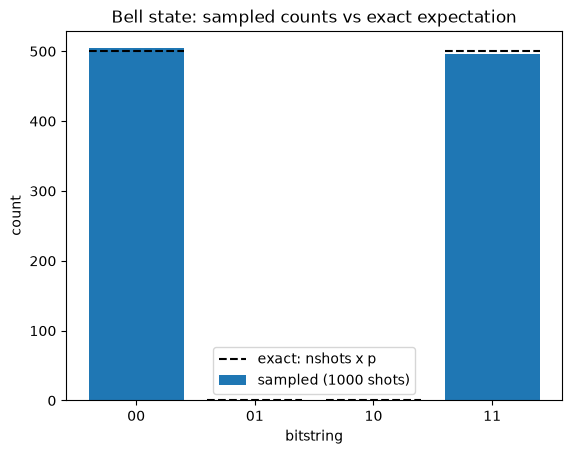

In [18]:
counts = bell_result.get_samples()
labels = sorted(exact_probs)                  # all four outcomes, including the never-seen ones
positions = range(len(labels))

plt.bar(positions, [counts.get(k, 0) for k in labels], tick_label=labels, label="sampled (1000 shots)")
for i, k in enumerate(labels):
    expected = 1000 * exact_probs[k]
    plt.hlines(expected, i - 0.4, i + 0.4, colors="black", linestyles="dashed",
               label="exact: nshots x p" if i == 0 else None)
plt.title("Bell state: sampled counts vs exact expectation")
plt.xlabel("bitstring")
plt.ylabel("count")
plt.legend()
plt.show()

Now follow the Bell circuit's state gate by gate to see *why* the two qubits always agree:

1. **Start:** $|00\rangle$. Both qubits are definitely 0.
2. **After $H$ on qubit 0:** $\tfrac{1}{\sqrt2}\,(|00\rangle + |10\rangle)$. Qubit 0 is now undecided, but qubit 1 is still definitely 0 in both branches. No entanglement yet: this is a product state.
3. **After `CNOT(0, 1)`:** $\tfrac{1}{\sqrt2}\,(|00\rangle + |11\rangle)$. Inside the branch where qubit 0 is 1, the CNOT flipped qubit 1. The gate did not decide the coin flip; it *copied the correlation*, tying the two qubits' outcomes together.

In short: $H$ creates the randomness, and CNOT distributes it. The pattern scales, too: each additional CNOT attaches one more qubit to the same coin flip, giving a ladder of qubits that all agree. This is the pattern the next exercise builds on.

### 🧩 Exercise 2.2: a shared secret for three parties

**The outcome you are engineering:** three parties (Alice, Bob, Charlie) each hold one qubit of a 3-qubit register. When they all measure, each receives the *same* random bit. Nobody chose the bit, it did not exist before the measurements, and an outsider cannot predict it. This correlation is the primitive behind **quantum secret sharing** and entanglement-based **key distribution**. Recall Part 1's collapse rule: measurement hands each party exactly one classical bit; the circuit's job is to choreograph the state so those three bits always agree.

Build the circuit and **prove** the correlation two ways:

1. Build a 3-qubit circuit in which all three qubits always agree on one random bit, then measure all three. Hint: the Bell recipe extends naturally, one source of randomness plus a ladder of CNOTs passing it along. Derive the gates from the step-through above rather than looking them up.
2. Sample 1000 shots and print the counts: only two bitstrings should ever appear, each around 500.
3. Prove it exactly: print the state-tomography probabilities (rounded). They should put exactly $0.5$ on each of the two all-agree outcomes and $0$ everywhere else.
4. Bar-plot the sampled counts.

This is the state Part 1 called GHZ, except now you have *built* it from gates instead of calling a factory function.

samples: {'000': 520, '111': 480}
exact  : {'000': 0.5, '001': 0.0, '010': 0.0, '011': 0.0, '100': 0.0, '101': 0.0, '110': 0.0, '111': 0.5}


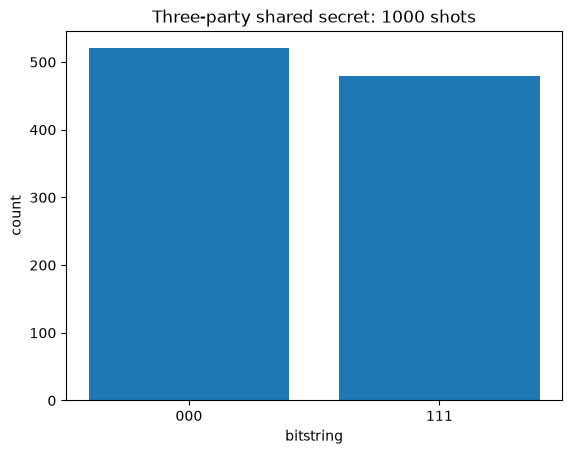

In [19]:
secret = Circuit(3)

# step 1: one coin flip, then a ladder of CNOTs passing it down the register
secret.add(H(0))
secret.add(CNOT(0, 1))
secret.add(CNOT(1, 2))
secret.add(M(0, 1, 2))

# step 2: sampled proof, only '000' and '111' ever appear
secret_result = QiliSim().execute(DigitalPropagation(secret), Readout().with_sampling(nshots=1000))
secret_counts = secret_result.get_samples()
print("samples:", secret_counts)

# step 3: exact proof: probability 0.5 on each all-agree outcome, 0 everywhere else
secret_exact = QiliSim().execute(DigitalPropagation(secret), Readout().with_state_tomography())
print("exact  :", {k: round(p, 6) for k, p in secret_exact.state_tomography.probabilities.items()})

# step 4: histogram of the sampled counts
secret_labels = sorted(secret_counts)
plt.bar(secret_labels, [secret_counts[k] for k in secret_labels])
plt.title("Three-party shared secret: 1000 shots")
plt.xlabel("bitstring")
plt.ylabel("count")
plt.show()

## Recap & what's next

- **Gates are unitary matrices.** A `Circuit` composes them with `.add(...)`, and applying $A$ then $B$ computes $B\,A\,|\psi\rangle$, in function-composition order. **Measurement** (`M`) is the one non-unitary step: it collapses the state into classical bits.
- Each single-qubit gate is a **rotation of the Bloch sphere**: $X$ is the **bit flip** ($|0\rangle\leftrightarrow|1\rangle$), $Z$ the **phase flip** ($|+\rangle\leftrightarrow|-\rangle$), and $H$ the bridge between the two bases. Any gate's matrix is available on **`.matrix`**.
- Applying $H$ twice returns $|0\rangle$ exactly: the simplest form of **interference**, where opposite-sign paths cancel — the mechanism every quantum algorithm relies on to make the right answers survive measurement.
- The universal execution call is **`Backend.execute(functional, readout)`**: wrap a circuit in `DigitalPropagation`, run it on `QiliSim`, read it out with the `Readout` builder.
- **Sampling** gives empirical counts with shot noise (shrinking like $1/\sqrt{\text{nshots}}$); **state tomography** gives exact probabilities, which only a simulator can provide. Use exact readout for reproducible numbers and sampling to mimic hardware.
- You built a **provably fair quantum coin** (a commercial QRNG at toy scale) and scaled it into a dice roller, then **entangled** qubits into a shared random bit that no outsider can predict.

**Next, Part 3, Hamiltonians & Analog Quantum Computing:** we compute the *other* way. Instead of discrete gates, we evolve a physical system continuously in time under a Hamiltonian, and use that to solve a real problem: scheduling four conference talks around their conflicts by quantum annealing.